# Exploratory Data Analysis: WDI and Olympic Performance

**Project:** Predicting Olympic Success from National Economic Conditions (IST 707)



In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = Path("Dataset")
if not (DATA_DIR / "WDI_raw_data.csv").exists():
    DATA_DIR = Path("../Dataset")

WDI_PATH = DATA_DIR / "WDI_raw_data.csv"
OLY_PATH = DATA_DIR / "olympics_data.csv"

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load data


In [2]:
wdi = pd.read_csv(WDI_PATH)
oly = pd.read_csv(OLY_PATH)
print("WDI:", wdi.shape)
print("Olympics:", oly.shape)
display(wdi.head(3))
display(oly.head(3))


WDI: (13530, 66)
Olympics: (2715, 10)


,ID,Country,Country Code,Year,Gross capital formation (% of GDP),Gross fixed capital formation (% of GDP),Multidimensional poverty headcount ratio (World Bank) (% of population),"Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)","Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)",GNI per capita (constant 2015 US$),Price level index (GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Imports of goods and services (% of GDP),Exports of goods and services (% of GDP),"Official exchange rate (LCU per US$, period average)",GDP growth (annual %),GDP per capita (current US$),GDP (current US$),"Droughts, floods, extreme temperatures (% of population, average 1990-2009)",General government final consumption expenditure (% of GDP),Urban population (% of total population),Domestic credit to private sector (% of GDP),Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Foreign direct investment, net inflows (% of GDP)","Foreign direct investment, net outflows (% of GDP)","Intentional homicides (per 100,000 people)",Control of Corruption - Governance estimate (approx. -2.5 to +2.5),Control of Corruption - Governance score (0-100),"CPIA transparency, accountability, and corruption in the public sector rating (1=low to 6=high)","School enrollment, secondary (% gross)","School enrollment, primary (% gross)","School enrollment, tertiary (% gross)","Government expenditure on education, total (% of GDP)","Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)",Current health expenditure (% of GDP),Gini index,"Children in employment, total (% of children ages 7-14)","Employment to population ratio, 15+, total (%) (modeled ILO estimate)","Agriculture, forestry, and fishing, value added (% of GDP)",Import value index (2015 = 100),Export value index (2015 = 100),"Population, total",Population growth (annual %),Population density (people per sq. km of land area),"Life expectancy at birth, total (years)","Central government debt, total (% of GDP)",Research and development expenditure (% of GDP),Individuals using the Internet (% of population),Tax revenue (% of GDP),CPIA trade rating (1=low to 6=high),CPIA social protection rating (1=low to 6=high),CPIA property rights and rule-based governance rating (1=low to 6=high),CPIA policies for social inclusion/equity cluster average (1=low to 6=high),CPIA gender equality rating (1=low to 6=high),CPIA business regulatory environment rating (1=low to 6=high),People using at least basic drinking water services (% of population),Prevalence of severe food insecurity in the population (%),"Mortality rate, under-5 (per 1,000 live births)","Fertility rate, total (births per woman)",CPIA equity of public resource use rating (1=low to 6=high),CPIA building human resources rating (1=low to 6=high),"International tourism, receipts (% of total exports)","International tourism, number of arrivals",Military expenditure (% of GDP),Access to electricity (% of population)
0,AFG60,Afghanistan,AFG,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.1966,NaN,NaN,NaN,NaN,NaN,8.1226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,035,043.0000",NaN,NaN,32.7990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,350.6000,7.2820,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG61,Afghanistan,AFG,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.1966,NaN,NaN,NaN,NaN,NaN,8.3896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,214,083.0000",1.9622,14.1270,33.2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345.2000,7.2840,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG62,Afghanistan,AFG,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.1966,NaN,NaN,NaN,NaN,NaN,8.6627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,404,406.0000",2.0445,14.4188,33.7570

,country,olympic_code,wdi_code,year,athlete_count,event_entries,gold,silver,bronze,total
0,Afghanistan,AFG,AFG,1960,12,16,0.0000,0.0000,0.0000,0.0000
1,Afghanistan,AFG,AFG,1964,8,8,0.0000,0.0000,0.0000,0.0000
2,Afghanistan,AFG,AFG,1968,5,5,0.0000,0.0000,0.0000,0.0000


## 2. WDI structure and coverage


In [4]:
ID_COLS = ["ID", "Country", "Country Code", "Year"]
ECON_COLS = [c for c in wdi.columns if c not in ID_COLS]

print("Economic columns:", len(ECON_COLS))
print("Years:", int(wdi["Year"].min()), "to", int(wdi["Year"].max()))
print("Countries:", wdi["Country Code"].nunique())

miss = (wdi[ECON_COLS].isna().mean() * 100).sort_values(ascending=False)
display(miss.head(20).to_frame("pct_missing"))




Economic columns: 62
Years: 1960 to 2025
Countries: 205


,pct_missing
Control of Corruption - Governance score (0-100),100.0000
Control of Corruption - Governance estimate (approx. -2.5 to +2.5),100.0000
Price level index (GDP),100.0000
"Droughts, floods, extreme temperatures (% of population, average 1990-2009)",98.7583
"Children in employment, total (% of children ages 7-14)",97.9231
Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),94.7894
Multidimensional poverty headcount ratio (World Bank) (% of population),92.4834
Prevalence of severe food insecurity in the population (%),91.6334
CPIA social protection rating (1=low to 6=high),88.2927
CPIA policies for social inclusion/equity cluster average (1=low to 6=high),88.2705


## 3. WDI missingness (cleaning guide)


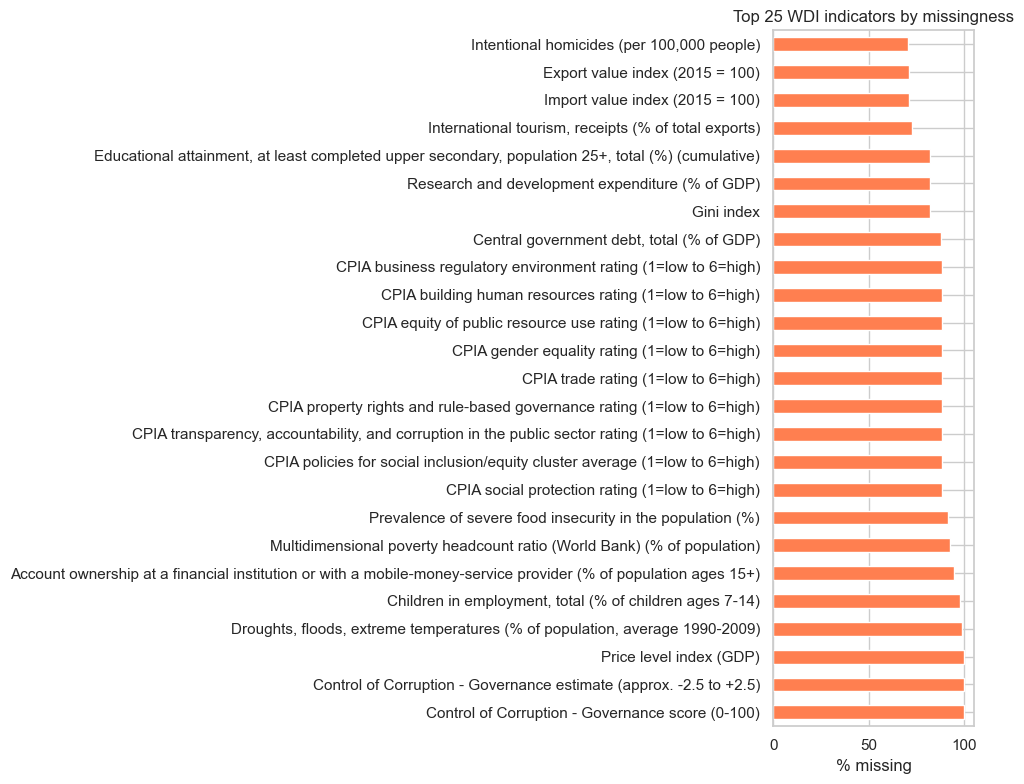

,avg_pct_missing_across_indicators
Country Code,
PRK,83.8954
VGB,82.6979
ASM,82.6246
CUW,81.6227
SSD,79.1789
CYM,79.1789
GUM,78.9101
LIE,78.7634
VIR,78.7146


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
miss.head(25).plot.barh(ax=ax, color="coral")
ax.set_xlabel("% missing")
ax.set_title("Top 25 WDI indicators by missingness")
plt.tight_layout()
plt.show()

country_miss = (
    wdi.groupby("Country Code")[ECON_COLS]
    .apply(lambda df: df.isna().mean().mean() * 100)
    .sort_values(ascending=False)
)
display(country_miss.head(15).to_frame("avg_pct_missing_across_indicators"))


## 4. WDI distributions (log scale for GDP / population)


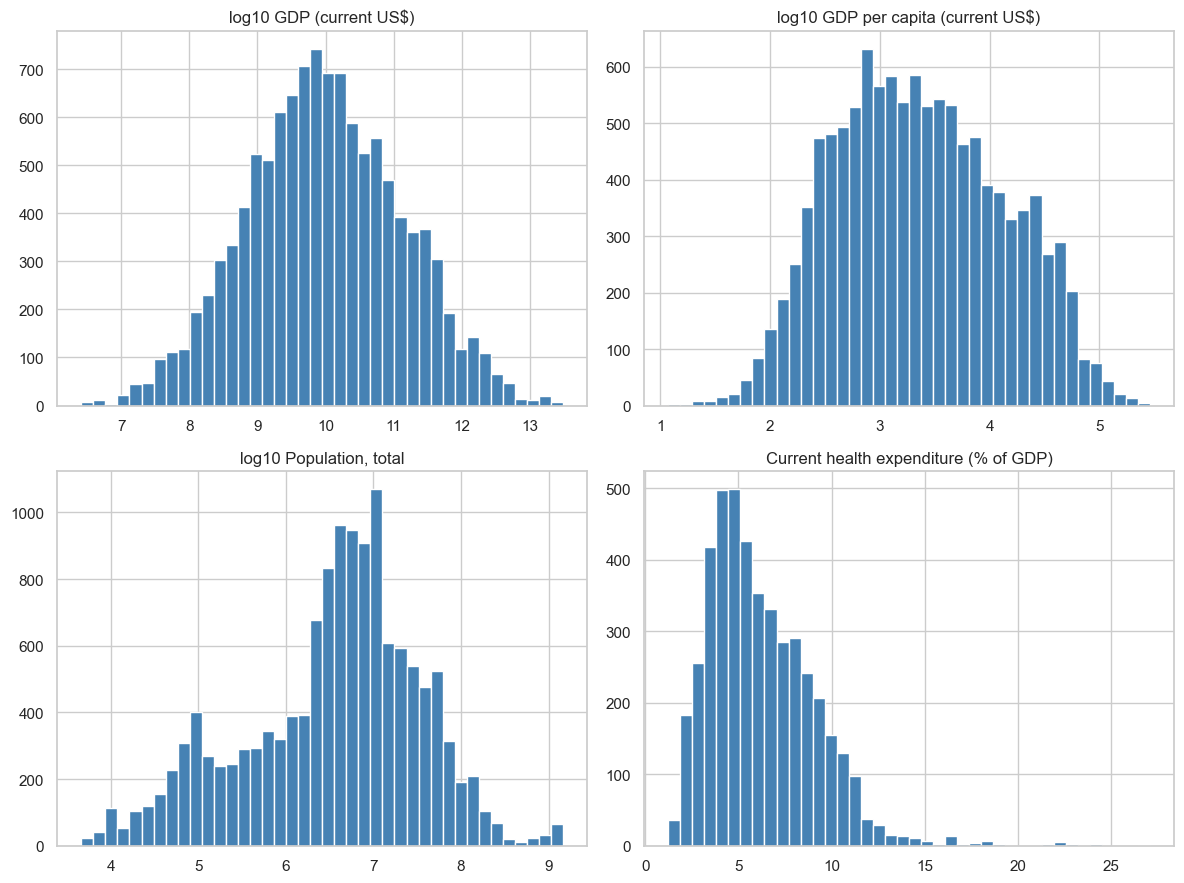

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
plots = [
    ("GDP (current US$)", True),
    ("GDP per capita (current US$)", True),
    ("Population, total", True),
    ("Current health expenditure (% of GDP)", False),
]
for ax, (col, use_log) in zip(axes.ravel(), plots):
    s = wdi[col].dropna()
    if use_log:
        s = np.log10(s[s > 0])
        ax.set_title("log10 " + col)
    else:
        ax.set_title(col)
    ax.hist(s, bins=40, color="steelblue", edgecolor="white")
plt.tight_layout()
plt.show()


Complete-case rows (1990-2016): 2082


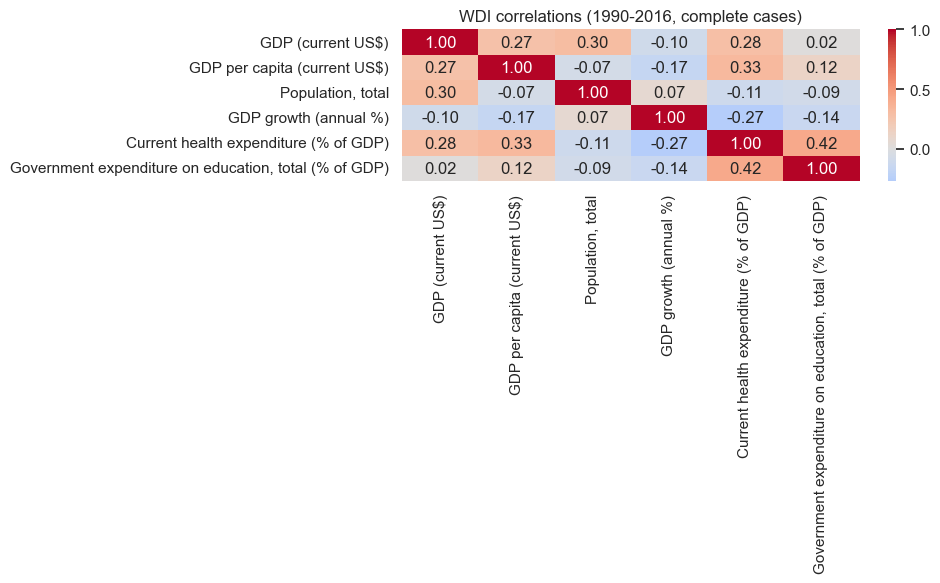

In [7]:
KEY = [
    "GDP (current US$)",
    "GDP per capita (current US$)",
    "Population, total",
    "GDP growth (annual %)",
    "Current health expenditure (% of GDP)",
    "Government expenditure on education, total (% of GDP)",
]
KEY = [c for c in KEY if c in wdi.columns]
sub = wdi[wdi["Year"].between(1990, 2016)][KEY].dropna()
print("Complete-case rows (1990-2016):", len(sub))
if len(sub) > 50:
    sns.heatmap(sub.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("WDI correlations (1990-2016, complete cases)")
    plt.tight_layout()
    plt.show()


## 5. Olympics data overview


In [8]:
print("Olympic years:", oly["year"].min(), "to", oly["year"].max())
print("Unique years:", oly["year"].nunique())
print("Countries:", oly["olympic_code"].nunique())
print("Rows with medals > 0:", (oly["total"] > 0).sum(), f"({(oly['total'] > 0).mean() * 100:.1f}%)")
display(oly[["total", "athlete_count", "event_entries"]].describe())

by_year = oly.groupby("year").agg(
    countries=("olympic_code", "nunique"),
    athletes=("athlete_count", "sum"),
    medals=("total", "sum"),
)
display(by_year.tail(10))


Olympic years: 1960 to 2016
Unique years: 21
Countries: 217
Rows with medals > 0: 1059 (39.0%)


,total,athlete_count,event_entries
count,"2,715.0000","2,715.0000","2,715.0000"
mean,5.0114,54.1860,76.5448
std,15.1090,94.1999,133.9684
min,0.0000,1.0000,1.0000
25%,0.0000,5.0000,6.0000
50%,0.0000,14.0000,19.0000
75%,3.0000,56.0000,76.0000
max,217.0000,693.0000,968.0000


,countries,athletes,medals
year,,,
1998,71,2172,205.0000
2000,197,10586,922.0000
2002,76,2393,234.0000
2004,199,10466,921.0000
2006,78,2493,252.0000
2008,202,10816,954.0000
2010,81,2535,258.0000
2012,202,10461,958.0000
2014,87,2741,295.0000


,,gold,silver,bronze,total
country,olympic_code,,,,
United States,USA,662.0000,547.0000,485.0000,"1,694.0000"
Soviet Union,URS,407.0000,314.0000,298.0000,"1,019.0000"
Germany,DEU,225.0000,232.0000,224.0000,681.0000
China,CHN,237.0000,189.0000,174.0000,600.0000
Russia,RUS,192.0000,163.0000,184.0000,539.0000
East Germany,GDR,192.0000,165.0000,162.0000,519.0000
Italy,ITA,161.0000,143.0000,178.0000,482.0000
France,FRA,132.0000,145.0000,192.0000,469.0000
Great Britain,GBR,141.0000,147.0000,168.0000,456.0000


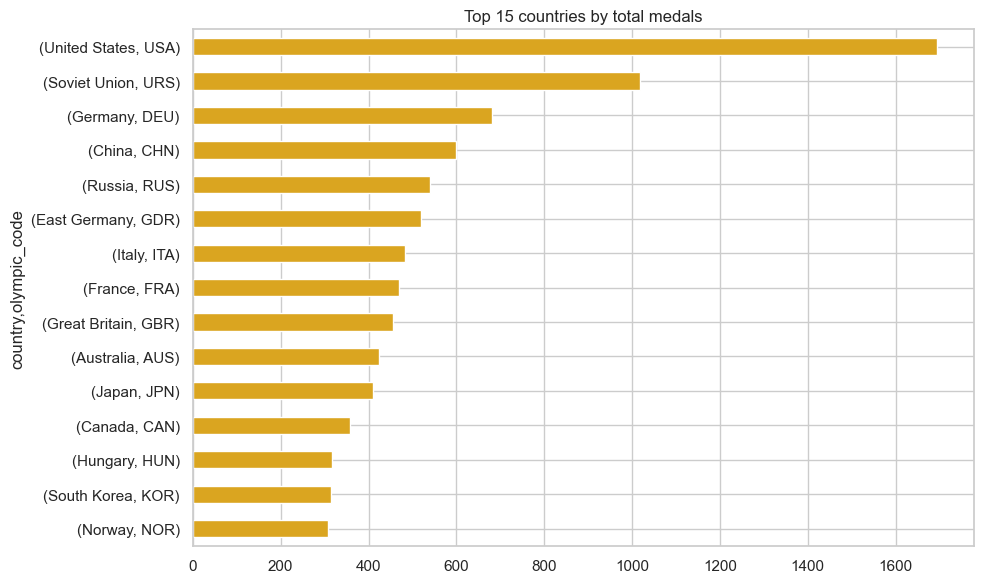

In [9]:
top = (
    oly.groupby(["country", "olympic_code"])[["gold", "silver", "bronze", "total"]]
    .sum()
    .sort_values("total", ascending=False)
    .head(15)
)
display(top)
top["total"].plot.barh(color="goldenrod", title="Top 15 countries by total medals")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Team size vs medals


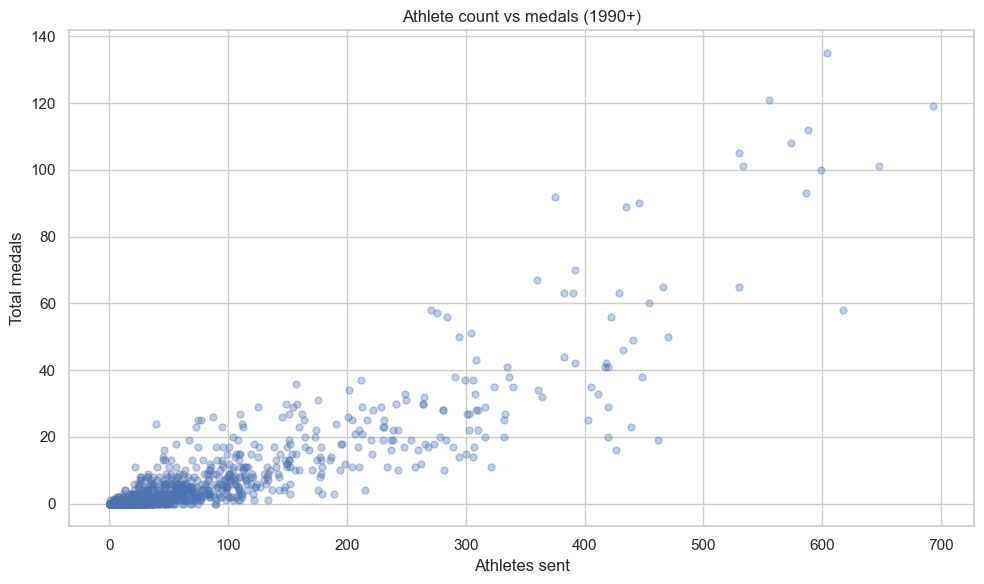

Pearson r: 0.8866282751755906
Spearman rho: 0.810045101341853


In [10]:
recent = oly[oly["year"] >= 1990]
plt.scatter(recent["athlete_count"], recent["total"], alpha=0.35, s=25)
plt.xlabel("Athletes sent")
plt.ylabel("Total medals")
plt.title("Athlete count vs medals (1990+)")
plt.tight_layout()
plt.show()
print("Pearson r:", recent["athlete_count"].corr(recent["total"]))
print("Spearman rho:", recent["athlete_count"].corr(recent["total"], method="spearman"))


## 7. WDI and Olympics


In [11]:
merged = oly.merge(
    wdi,
    left_on=["wdi_code", "year"],
    right_on=["Country Code", "Year"],
    how="inner",
)
print("Olympics rows:", len(oly))
print("Merged rows:", len(merged))
print("Unmatched Olympic rows:", len(oly) - len(merged))

for code, yr in [("USA", 2016), ("CHN", 2016), ("KEN", 2016), ("AFG", 2016)]:
    r = merged[(merged["olympic_code"] == code) & (merged["year"] == yr)]
    if len(r):
        row = r.iloc[0]
        print(
            code,
            yr,
            "athletes",
            row["athlete_count"],
            "medals",
            row["total"],
            "gdp_pc",
            row["GDP per capita (current US$)"],
        )


Olympics rows: 2715
Merged rows: 2661
Unmatched Olympic rows: 54
USA 2016 athletes 555 medals 121.0 gdp_pc 57976.6282
CHN 2016 athletes 392 medals 70.0 gdp_pc 8254.868593
KEN 2016 athletes 79 medals 13.0 gdp_pc 1554.126103
AFG 2016 athletes 3 medals 0.0 gdp_pc 522.0822156


## 8. Economics vs medals (1990-2016 panel)


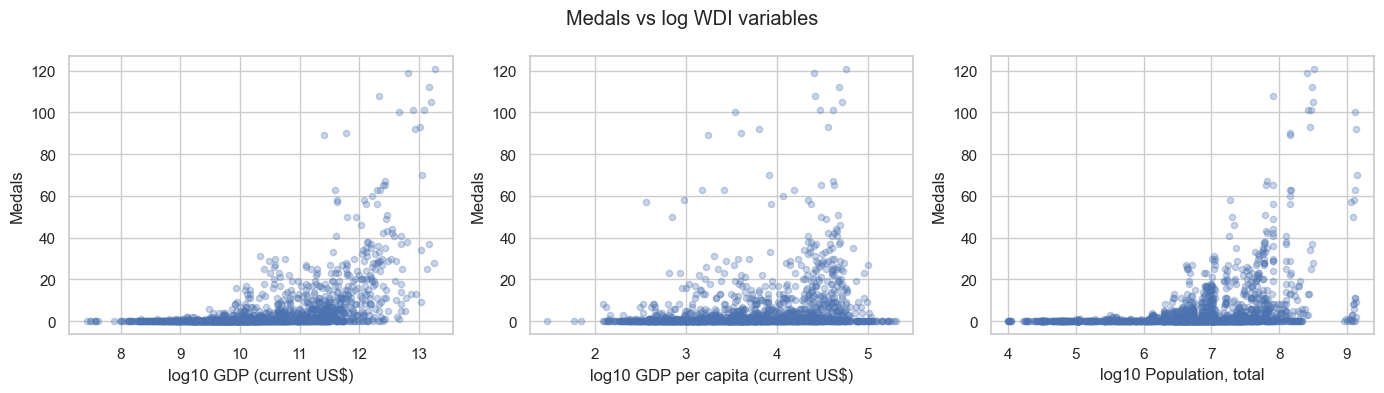

In [12]:
m = merged[merged["year"].between(1990, 2016)].copy()
for col in ["GDP (current US$)", "GDP per capita (current US$)", "Population, total"]:
    m["log_" + col] = np.log10(m[col].replace(0, np.nan))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(
    axes,
    [
        "log_GDP (current US$)",
        "log_GDP per capita (current US$)",
        "log_Population, total",
    ],
):
    ax.scatter(m[col], m["total"], alpha=0.3, s=20)
    ax.set_xlabel(col.replace("log_", "log10 "))
    ax.set_ylabel("Medals")
plt.suptitle("Medals vs log WDI variables")
plt.tight_layout()
plt.show()


## 9. Stakeholder metrics (2016 snapshot)


In [15]:
snap = m[(m["year"] == 2016) & (m["GDP (current US$)"] > 0)].copy()
snap["log_gdp"] = np.log10(snap["GDP (current US$)"])
snap["medals_per_log_gdp"] = snap["total"] / snap["log_gdp"]

display(
    snap[snap["total"] > 0]
    .nlargest(10, "medals_per_log_gdp")[
        ["country", "athlete_count", "total", "GDP (current US$)", "medals_per_log_gdp"]
    ]
)

coefs = np.polyfit(snap["log_gdp"], snap["total"], 1)
snap["expected"] = np.polyval(coefs, snap["log_gdp"])
snap["residual"] = snap["total"] - snap["expected"]
display(snap.nlargest(8, "residual")[["country", "total", "expected", "residual"]])
display(snap.nsmallest(8, "residual")[["country", "total", "expected", "residual"]])


,country,athlete_count,total,GDP (current US$),medals_per_log_gdp
2548,United States,555,121.0000,"18,804,900,000,000.0000",9.1154
930,Great Britain,360,67.0000,"2,706,810,000,000.0000",5.3891
532,China,392,70.0000,"11,456,000,000,000.0000",5.3603
2037,Russia,284,56.0000,"1,276,790,000,000.0000",4.6258
849,France,392,42.0000,"2,470,410,000,000.0000",3.3891
895,Germany,418,42.0000,"3,536,790,000,000.0000",3.3470
1260,Japan,335,41.0000,"5,110,360,000,000.0000",3.2262
143,Australia,420,29.0000,"1,211,590,000,000.0000",2.4000
1220,Italy,309,28.0000,"1,887,110,000,000.0000",2.2809
456,Canada,310,22.0000,"1,528,000,000,000.0000",1.8056


,country,total,expected,residual
2548,United States,121.0000,24.7386,96.2614
930,Great Britain,67.0000,18.7218,48.2782
532,China,70.0000,23.2002,46.7998
2037,Russia,56.0000,16.3893,39.6107
849,France,42.0000,18.4382,23.5618
895,Germany,42.0000,19.5520,22.4480
1260,Japan,41.0000,20.6945,20.3055
2492,Tuvalu,0.0000,-15.7033,15.7033


,country,total,expected,residual
1115,India,2.0000,18.2093,-16.2093
2111,Saudi Arabia,0.0000,14.4758,-14.4758
1128,Indonesia,3.0000,15.4119,-12.4119
1053,Hong Kong,0.0000,12.1023,-12.1023
1857,Pakistan,0.0000,12.0316,-12.0316
1795,Nigeria,1.0000,12.8225,-11.8225
164,Austria,1.0000,12.7372,-11.7372
2527,United Arab Emirates,1.0000,12.6414,-11.6414


## 10. Feature screening for modeling


In [16]:
panel = merged[merged["year"].between(1990, 2016)]
miss_panel = panel[ECON_COLS].isna().mean().sort_values()
keep = miss_panel[miss_panel <= 0.5]
drop = miss_panel[miss_panel > 0.5]
print("Keep (<=50% missing):", len(keep))
print("Drop/review (>50% missing):", len(drop))
display(drop.head(15).to_frame("pct_missing"))


Keep (<=50% missing): 39
Drop/review (>50% missing): 23


,pct_missing
Import value index (2015 = 100),0.5510
Export value index (2015 = 100),0.5510
Research and development expenditure (% of GDP),0.5741
Gini index,0.6066
"Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)",0.6375
"Central government debt, total (% of GDP)",0.7466
CPIA trade rating (1=low to 6=high),0.8518
CPIA property rights and rule-based governance rating (1=low to 6=high),0.8518
CPIA policies for social inclusion/equity cluster average (1=low to 6=high),0.8518
CPIA gender equality rating (1=low to 6=high),0.8518


## 11. Summary and next steps

1. Medal counts are zero-heavy; We should consider logistic (won medal) and regression (count) baselines.
2. Athlete count aligns with medals (team size effect).
3. GDP, population, health, and education correlate with medals, consistent with literature.
4. WDI missingness is uneven; We should avoid cleaning rules that drop low-income countries.
5. Best joint window for modeling: **1990-2016**.

